### **1. Setup & Imports**

This section handles the initial setup of the environment. It installs necessary Python packages, imports all required libraries from these packages

In [67]:
%%capture
!pip install -U peft torchao optuna

In [68]:
import random
import time
import re
from typing import Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, TaskType, get_peft_model

import optuna

from warnings import filterwarnings
filterwarnings('ignore')

In [69]:
# ============================================================
# Check if current device is GPU
# ============================================================
if torch.cuda.is_available():
    print("Running on GPU!")
    DEVICE = torch.device("cuda")
else:
    print("Running on CPU!")
    DEVICE = torch.device("cpu")

# Set a global seed for reproducibility
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_global_seed(SEED)
print(f"Global random seed set to {SEED}")

Running on GPU!
Global random seed set to 42


### **2. Dataset Loading & EDA**
The dataset combines formal financial news sentences with short, informal stock market tweets, all labelled positive, negative, or neutral. [`Kaggle Dataset Link`](https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis)

In [70]:
# Load data into dataframe
DATA_URL = (
    "https://raw.githubusercontent.com/faadeola/LLM-financial-sentiment-analysis/"
    "refs/heads/main/Financial%20Sentiment%20Analysis%20Data.csv"
)

df = pd.read_csv(DATA_URL)
print(f'The dataset contains{df.shape[0]} rows and {df.shape[1]} columns \n')
df.head()

The dataset contains5842 rows and 2 columns 



,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [71]:
# Display counts of labels
df["Sentiment"].value_counts()

,count
Sentiment,
neutral,3130
positive,1852
negative,860


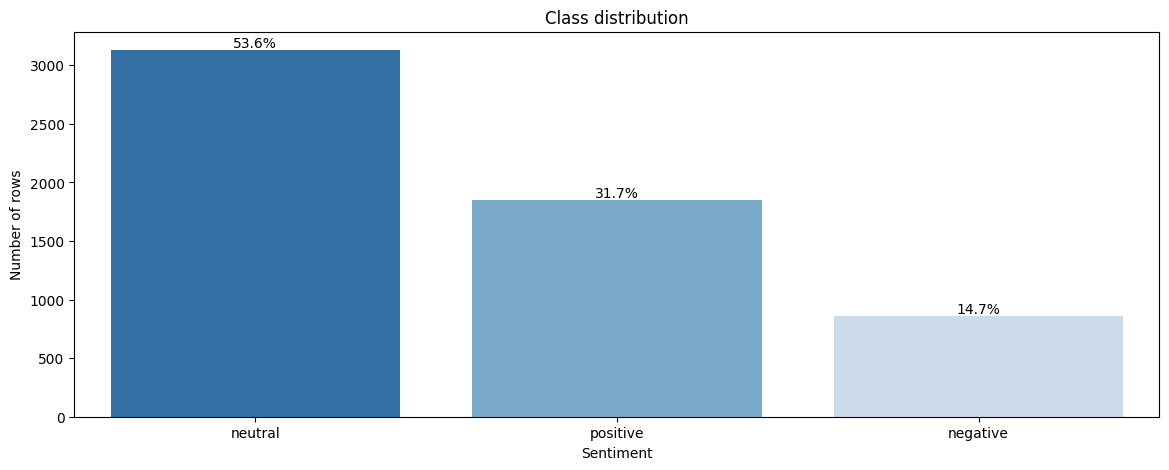

In [72]:
class_counts = df["Sentiment"].value_counts()
class_props = df["Sentiment"].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette='Blues_r')
ax.set_title("Class distribution")
ax.set_ylabel("Number of rows")
for i, (count, prop) in enumerate(zip(class_counts.values, class_props.values)):
    ax.text(i, count + 20, f"{prop:.1%}", ha="center")
plt.show()

In [73]:
print("Missing values:")
print(df.isnull().sum())

print("\nExact duplicate rows (same sentence and same label):", df.duplicated().sum())
print("Duplicate sentences (any label):", df["Sentence"].duplicated().sum())

repeated = df[df["Sentence"].duplicated(keep=False)]
label_conflicts = repeated.groupby("Sentence")["Sentiment"].nunique()
label_conflicts = label_conflicts[label_conflicts > 1]
print("Sentences that appear more than once with different labels:", len(label_conflicts))

Missing values:
Sentence     0
Sentiment    0
dtype: int64

Exact duplicate rows (same sentence and same label): 6
Duplicate sentences (any label): 520
Sentences that appear more than once with different labels: 514


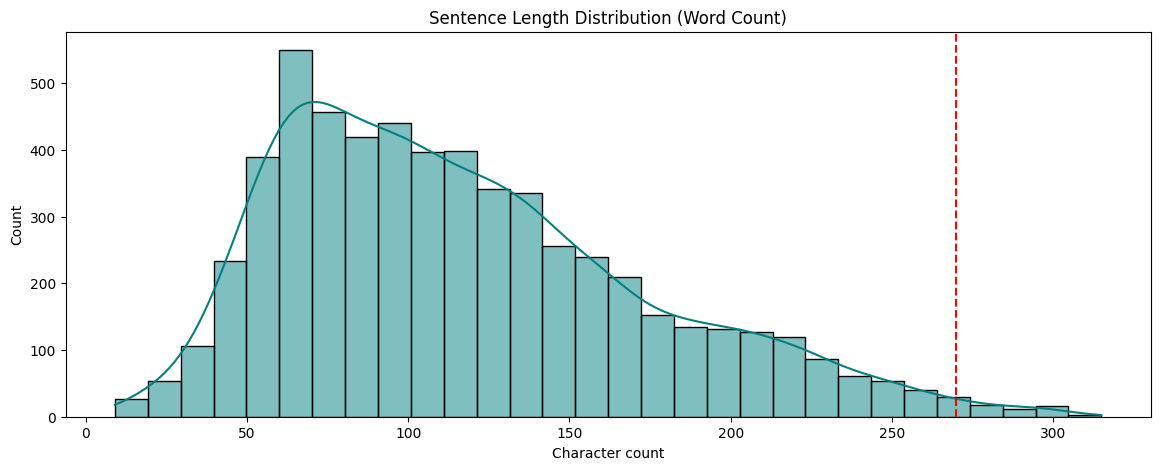

,char_length
count,5842.000000
mean,117.022253
std,56.420425
min,9.000000
25%,72.000000
50%,107.000000
75%,150.000000
max,315.000000


In [74]:
df["char_length"] = df["Sentence"].str.len()

fig, ax = plt.subplots(figsize=(14, 5))
sns.histplot(df["char_length"], ax=ax, kde=True, color='teal', bins=30)
plt.axvline(x=df["char_length"].quantile(0.99), color="red", linestyle="--", label='99th Percentile')
ax.set_title("Sentence Length Distribution (Word Count)")
ax.set_xlabel("Character count")
plt.show()

df["char_length"].describe()

In [75]:
# Flag sentence that contains tweet style format (hashtags)
tweet_pattern = r"\$[A-Za-z]+|https?://|#\w+"
df["looks_like_tweet"] = df["Sentence"].str.contains(tweet_pattern, regex=True)
df["looks_like_tweet"].value_counts()

,count
looks_like_tweet,
False,5167
True,675


### **3. Cleaning and Preprocessing**

In [76]:
# function to clean text in one go
def clean_text(text):
    """Basic text cleaning function for Transformer models."""
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'\s+', ' ', text).strip()   # Remove redundant whitespace
    return text

In [77]:
df_clean = df.copy()
df_clean["Sentence"] = df_clean["Sentence"].apply(clean_text)

rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["Sentence", "Sentiment"]).reset_index(drop=True)
print(f"Rows before: {rows_before}, rows after cleaning and dropping exact duplicates: {len(df_clean)}")

df_clean = df_clean[["Sentence", "Sentiment"]].copy()

Rows before: 5842, rows after cleaning and dropping exact duplicates: 5831


In [78]:
label_encoder = LabelEncoder()
df_clean["label"] = label_encoder.fit_transform(df_clean["Sentiment"])

label_map = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:", label_map)

class_names = label_encoder.classes_.tolist()

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [79]:
# dataset splitting for llm trainings
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    df_clean["Sentence"].tolist(),
    df_clean["label"].tolist(),
    test_size=0.15,
    random_state=SEED,
    stratify=df_clean["label"],
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts,
    train_val_labels,
    test_size=0.15,
    random_state=SEED,
    stratify=train_val_labels,
)

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

Train: 4212, Val: 744, Test: 875


In [80]:
"""
  The baseline doesn't need held out validation set for early stopping,
  so it trains on train+val while FinBERT trains on train only and monitors on val. So, both are evaluated on the same test set.
"""
baseline_train_texts = train_texts + val_texts
baseline_train_labels = train_labels + val_labels

### **4. Reusable Functions**

In [81]:
def get_metrics(y_true, y_pred, average="macro"):
    """Return accuracy, precision, recall, and F1 as a plain dict"""
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    """Plot a confusion matrix and return the confusion matrix object"""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.show()
    return cm


def show_results(model_name, texts, y_true, y_pred, label_encoder, class_names, n_rows=10):
    """Print metrics and a text/actual/predicted table for one model"""
    print(f"--- {model_name} ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    preds_df = pd.DataFrame({
        "text": texts,
        "actual": label_encoder.inverse_transform(y_true),
        "predicted": label_encoder.inverse_transform(y_pred),
    })
    display(preds_df.head(n_rows))

    return preds_df


def plot_loss_curve(history, title):
    """Plot the loss curve for model"""
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(epochs_range, history["train_loss"], marker="o", label="Train loss")
    ax.plot(epochs_range, history["val_loss"], marker="o", label="Validation loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    plt.show()


results = {}

### **5. Baseline Model: TF-IDF + Logistic Regression**
This section is divided into the baseline model with default parameters and then optimized parameters

#### **5.1 Baseline Model (Default)**

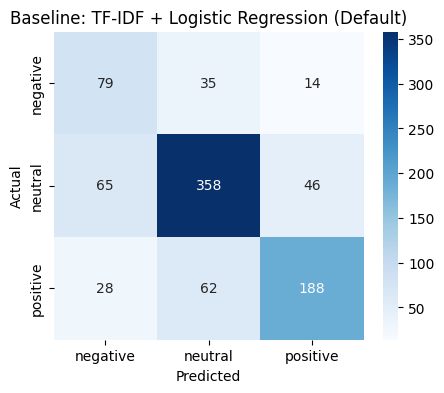

--- Baseline (default) ---
              precision    recall  f1-score   support

    negative       0.46      0.62      0.53       128
     neutral       0.79      0.76      0.77       469
    positive       0.76      0.68      0.71       278

    accuracy                           0.71       875
   macro avg       0.67      0.69      0.67       875
weighted avg       0.73      0.71      0.72       875



,text,actual,predicted
0,Finnish Kemira 's net sales EUR decreased to E...,negative,negative
1,"Therefore , the company 's 2005 result will re...",negative,neutral
2,@CH_Roark: $UNXL I like this Ascending Triangl...,positive,negative
3,$AAPL Clearing this descending trend line / bu...,positive,positive
4,`` Leipurin is a growing and rapidly internati...,positive,neutral
5,"ADP News - Nov 18 , 2008 - Finnish AC drives m...",positive,positive
6,Aldata said that there are still a number of o...,neutral,neutral
7,Finnish software developer Done Solutions Oyj ...,positive,positive
8,"F-Secure , a developer of security solutions a...",neutral,neutral
9,Panostaja did not disclose the purchase price .,neutral,neutral


In [82]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(baseline_train_texts)
X_test_tfidf = vectorizer.transform(test_texts)

baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced")
baseline_model.fit(X_train_tfidf, baseline_train_labels)

baseline_preds = baseline_model.predict(X_test_tfidf)

plot_confusion_matrix(test_labels, baseline_preds, class_names, "Baseline: TF-IDF + Logistic Regression (Default)")

baseline_preds_df = show_results(
    "Baseline (default)", test_texts, test_labels, baseline_preds,
    label_encoder, class_names,
)

In [83]:
results["baseline"] = get_metrics(test_labels, baseline_preds)
results["baseline"]

{'accuracy': 0.7142857142857143,
 'precision': 0.6680600095078715,
 'recall': 0.6855909062728495,
 'f1': 0.6721291129656147}

#### **5.2 Baseline Model (Optimized)**
`RandomizedSearchCV` samples a fixed number of parameter combinations (`n_iter`) instead of
trying every combination, which keeps the search fast. The vectorizer and classifier are
wrapped in a `Pipeline` so TF-IDF is refit on each cross-validation fold, avoiding leakage.

In [84]:
baseline_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

param_distributions = {
    "tfidf__max_features": [5000, 10000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 1, 10],
}

baseline_search = RandomizedSearchCV(
    baseline_pipeline,
    param_distributions,
    n_iter=6,
    scoring="f1_macro",
    cv=3,
    random_state=SEED,
    n_jobs=-1,
)

baseline_search.fit(baseline_train_texts, baseline_train_labels)

print("Best baseline params:", baseline_search.best_params_)

optimized_baseline_model = baseline_search.best_estimator_
optimized_baseline_preds = optimized_baseline_model.predict(test_texts)

Best baseline params: {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 5000, 'clf__C': 1}


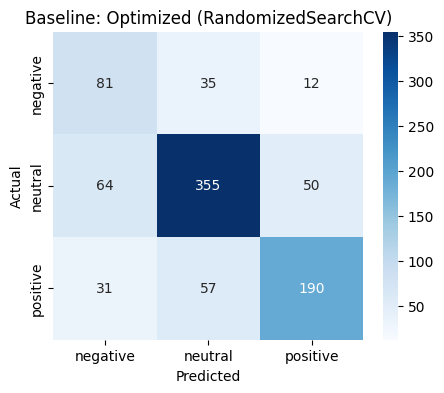

--- Baseline (optimized) ---
              precision    recall  f1-score   support

    negative       0.46      0.63      0.53       128
     neutral       0.79      0.76      0.78       469
    positive       0.75      0.68      0.72       278

    accuracy                           0.72       875
   macro avg       0.67      0.69      0.67       875
weighted avg       0.73      0.72      0.72       875



,text,actual,predicted
0,Finnish Kemira 's net sales EUR decreased to E...,negative,negative
1,"Therefore , the company 's 2005 result will re...",negative,neutral
2,@CH_Roark: $UNXL I like this Ascending Triangl...,positive,negative
3,$AAPL Clearing this descending trend line / bu...,positive,positive
4,`` Leipurin is a growing and rapidly internati...,positive,neutral
5,"ADP News - Nov 18 , 2008 - Finnish AC drives m...",positive,positive
6,Aldata said that there are still a number of o...,neutral,neutral
7,Finnish software developer Done Solutions Oyj ...,positive,positive
8,"F-Secure , a developer of security solutions a...",neutral,neutral
9,Panostaja did not disclose the purchase price .,neutral,neutral


In [85]:
plot_confusion_matrix(test_labels, optimized_baseline_preds, class_names, "Baseline: Optimized (RandomizedSearchCV)")

baseline_opt_preds_df = show_results(
    "Baseline (optimized)", test_texts, test_labels, optimized_baseline_preds,
    label_encoder, class_names,
)

In [86]:
results["baseline_optimized"] = get_metrics(test_labels, optimized_baseline_preds)
results["baseline_optimized"]

{'accuracy': 0.7154285714285714,
 'precision': 0.6694596572952278,
 'recall': 0.6910651249789082,
 'f1': 0.6749950130744179}

### **6. Fine-tuned Finbert Model**

#### **6.1 Tokenization and Dataset Preparation**

In [87]:
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LENGTH = 64

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [88]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            texts, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, MAX_LENGTH)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 4212
Val dataset size: 744
Test dataset size: 875


In [89]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels,
)
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float).to(DEVICE)

for name, weight in zip(class_names, class_weights_array):
    print(f"{name}: weight {weight:.3f}")

loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

negative: weight 2.265
neutral: weight 0.622
positive: weight 1.051


#### **6.2 Model Building and Training**
This section is used for the `fine-tuned finbert model` using `torch` and training loop composed of appropriate optimizer and loss function. Also, the fine-tuned model was trained using default parameter and also optimized parameter using `Optuna` for hyperparameter search and `LoRa` for optimization.

In [90]:
def build_model(use_lora=False, lora_config=None):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(class_names)
    )

    if use_lora:
        if lora_config is None:
            # Default LoRA config if not provided
            lora_config = LoraConfig(
                r=8,
                lora_alpha=16,
                target_modules=["query", "value"],
                lora_dropout=0.1,
                bias="none",
                task_type=TaskType.SEQ_CLS,
            )
        model = get_peft_model(model, lora_config)
        model.print_trainable_parameters()

    return model.to(DEVICE)


def run_training_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0

    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(labels)

    return running_loss / len(dataloader.dataset)


def run_evaluation(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            running_loss += loss.item() * len(labels)

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader.dataset)
    return avg_loss, all_preds, all_labels


def train_model(model, train_loader, val_loader, optimizer, loss_fn, device, epochs):
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        start = time.time()
        train_loss = run_training_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, _, _ = run_evaluation(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        elapsed = time.time() - start
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | "
            f"{elapsed:.1f}s"
        )

    return model, history

##### **6.2.1 FinbertfFine-tuned model (Default Hyperparameters)**

In [91]:
DEFAULT_LEARNING_RATE = 2e-5
DEFAULT_BATCH_SIZE = 16
DEFAULT_EPOCHS = 3

default_train_loader = DataLoader(train_dataset, batch_size=DEFAULT_BATCH_SIZE, shuffle=True)
default_val_loader = DataLoader(val_dataset, batch_size=DEFAULT_BATCH_SIZE)
default_test_loader = DataLoader(test_dataset, batch_size=DEFAULT_BATCH_SIZE)

default_model = build_model(use_lora=True)
default_optimizer = AdamW(default_model.parameters(), lr=DEFAULT_LEARNING_RATE)

default_model, default_history = train_model(
    default_model, default_train_loader, default_val_loader,
    default_optimizer, loss_fn, DEVICE, DEFAULT_EPOCHS,
)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


trainable params: 297,219 || all params: 109,781,766 || trainable%: 0.2707
Epoch 1/3 | train loss: 1.8059 | val loss: 1.0002 | 36.1s
Epoch 2/3 | train loss: 0.7769 | val loss: 0.6011 | 30.9s
Epoch 3/3 | train loss: 0.5696 | val loss: 0.5040 | 32.5s


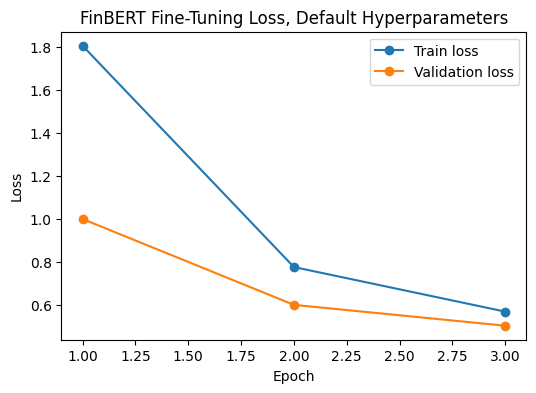

In [92]:
plot_loss_curve(default_history, "FinBERT Fine-Tuning Loss, Default Hyperparameters")

_, default_test_preds, default_test_labels = run_evaluation(
    default_model, default_test_loader, loss_fn, DEVICE
)

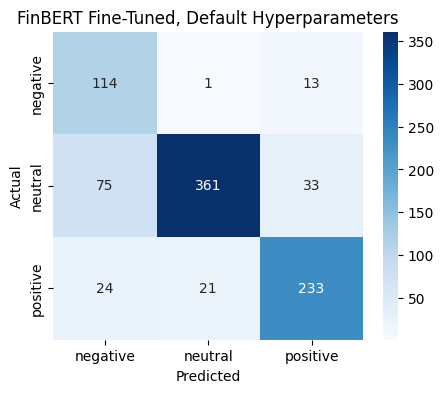

--- FinBERT (default) ---
              precision    recall  f1-score   support

    negative       0.54      0.89      0.67       128
     neutral       0.94      0.77      0.85       469
    positive       0.84      0.84      0.84       278

    accuracy                           0.81       875
   macro avg       0.77      0.83      0.78       875
weighted avg       0.85      0.81      0.82       875



,text,actual,predicted
0,Finnish Kemira 's net sales EUR decreased to E...,negative,negative
1,"Therefore , the company 's 2005 result will re...",negative,negative
2,@CH_Roark: $UNXL I like this Ascending Triangl...,positive,positive
3,$AAPL Clearing this descending trend line / bu...,positive,positive
4,`` Leipurin is a growing and rapidly internati...,positive,positive
5,"ADP News - Nov 18 , 2008 - Finnish AC drives m...",positive,positive
6,Aldata said that there are still a number of o...,neutral,neutral
7,Finnish software developer Done Solutions Oyj ...,positive,positive
8,"F-Secure , a developer of security solutions a...",neutral,positive
9,Panostaja did not disclose the purchase price .,neutral,neutral


{'accuracy': 0.8091428571428572,
 'precision': 0.7709651541235334,
 'recall': 0.8328257703006039,
 'f1': 0.7842214389462784}

In [93]:
plot_confusion_matrix(
    default_test_labels, default_test_preds, class_names,
    "FinBERT Fine-Tuned, Default Hyperparameters",
)

finbert_default_preds_df = show_results(
    "FinBERT (default)", test_texts, default_test_labels, default_test_preds,
    label_encoder, class_names,
)

results["finetuned_default"] = get_metrics(default_test_labels, default_test_preds)
results["finetuned_default"]